Master CSV (train.csv) Explore

In [1]:
import pandas as pd
from IPython.display import display

MASTER_CSV = r"C:\Users\aashi\Desktop\FYP\EDA\train.csv"

df = pd.read_csv(MASTER_CSV)


def show_section(title):
    print(f"\n{'=' * 60}")
    print(title)
    print(f"{'=' * 60}")


show_section("First few rows")
display(df.head())

show_section("Dataset shape")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

show_section("Column names")
print("\n".join(df.columns))

show_section("Missing values")
missing = df.isnull().sum()
display(missing[missing > 0].to_frame(name="missing_count"))

show_section("UPDRS distribution")
display(
    df["doctor_diagnosis_0_5"]
    .value_counts()
    .sort_index()
    .rename_axis("doctor_diagnosis_0_5")
    .reset_index(name="count")
)

show_section("Top folder paths")
display(
    df["folder_path"]
    .value_counts()
    .head(10)
    .rename_axis("folder_path")
    .reset_index(name="count")
)



First few rows


,data_file_name,folder_path,gender,age,patient_off_on,doctor_diagnosis_0_5
0,raw_data_d786d645-db38-11ec-b494-e82aea2c97f4.csv,Kinetic tremor,Male,52,off,1
1,raw_data_bdcba44f-0d6a-11ed-8857-b6da2cf29e9d.csv,Postural tremor,Male,78,on,0
2,raw_data_750c0f09-b09a-11ec-9699-58a023d3f6d9.csv,Postural tremor,Male,71,on,0
3,raw_data_d90846c3-3969-11ed-a96d-b469216ca443.csv,Fist,Male,23,off,1
4,raw_data_c27fbeb3-1882-11ed-95c1-b469216ca443.csv,Kinetic tremor,Male,23,off,2



Dataset shape
Rows: 833
Columns: 6

Column names
data_file_name
folder_path
gender
age
patient_off_on
doctor_diagnosis_0_5

Missing values


,missing_count



UPDRS distribution


,doctor_diagnosis_0_5,count
0,0,198
1,1,197
2,2,214
3,3,178
4,4,46



Top folder paths


,folder_path,count
0,Postural tremor,215
1,Fist,199
2,Finger tapping,196
3,Kinetic tremor,162
4,Pronation and supination of the hand,61


Finger Tapping in Master CSV

In [ ]:
#saved finger tapping rows to a new csv file
finger_tapping_df = df[
    df["folder_path"].astype(str).str.fullmatch("Finger tapping", case=False, na=False)
].copy()

print(finger_tapping_df)

finger_tapping_df.to_csv("finger_tapping_rows.csv", index=False)

print("Saved rows:", len(finger_tapping_df))
print("Output file:", "finger_tapping_rows.csv")

                                        data_file_name     folder_path  \
5    raw_data_af753f25-2ce9-11ed-b9a2-e82aea2c97f4.csv  Finger tapping   
12   raw_data_50a1a7ef-b3e9-11ec-82ad-e82aea2c97f4.csv  Finger tapping   
20   raw_data_a2c7fb0f-2f67-11ed-8b72-e82aea2c97f4.csv  Finger tapping   
29   raw_data_80c83c65-e86c-11ec-8d35-fd71ae554d63.csv  Finger tapping   
42   raw_data_cfa563e1-2205-11ed-a68f-b469216ca443.csv  Finger tapping   
..                                                 ...             ...   
802  raw_data_9dc1c3ab-f901-11ec-bdce-b469216ca443.csv  Finger tapping   
816  raw_data_d1a0e1e9-dbde-11ec-a19c-9248d38b455f.csv  Finger tapping   
817  raw_data_601aaadc-c15d-11ec-91ca-e82aea2c97f4.csv  Finger tapping   
826  raw_data_712bee8b-6fcc-11ed-8526-e82aea2c97f4.csv  Finger tapping   
827  raw_data_2002c55b-1c65-11ed-b3e1-b469216ca443.csv  Finger tapping   

     gender  age patient_off_on  doctor_diagnosis_0_5  
5      Male   70            off                     3  

Extracted Finger tapping CSV files 

In [4]:
import os
import shutil


# --- CONFIGURATION ---
# Path to your main CSV file that contains the usernames
MAIN_CSV_PATH = r"C:\Users\aashi\Desktop\FYP\EDA\finger_tapping_rows.csv"
# The column name in the main CSV containing the usernames
USERNAME_COLUMN = "data_file_name"

# Folder containing all the individual CSVs (including the unrelated ones)
SOURCE_FOLDER = r"C:\Users\aashi\Desktop\FYP\Datasets\data"
# The new folder where you want to copy the related CSVs
DESTINATION_FOLDER = r"C:\Users\aashi\Desktop\FYP\EDA\finger tapping individual csv"
# ---------------------

# 1. Create the destination folder if it doesn't exist yet
#os.makedirs(DESTINATION_FOLDER, exist_ok=True)

# 2. Load the valid usernames from your main CSV
try:
    df = pd.read_csv(MAIN_CSV_PATH)
    # Extract unique usernames and drop any NaN values, converting them to strings
    valid_usernames = set(df[USERNAME_COLUMN].dropna().astype(str).unique())
    print(f"Loaded {len(valid_usernames)} unique usernames from the main CSV.")
except Exception as e:
    print(f"Error reading the main CSV: {e}")
    exit()

# 3. Iterate through the source folder and copy matching files
copied_count = 0
missing_count = 0

for username in valid_usernames:
    # Construct the expected filename (e.g., "john_doe.csv")
    # Adjust the string formatting if your files have a suffix like "_data.csv"
    filename = str(username)
    source_file_path = os.path.join(SOURCE_FOLDER, filename)
    destination_file_path = os.path.join(DESTINATION_FOLDER, filename)

    # Check if the file actually exists in the source folder
    if os.path.exists(source_file_path):
        shutil.copy2(source_file_path, destination_file_path)  # copy2 preserves metadata
        copied_count += 1
    else:
        # Useful for identifying if any user in your main CSV is missing a file
        print(f"Warning: File not found for user '{username}' ({filename})")
        missing_count += 1

print("---")
print(f"Task complete! Copied {copied_count} files to '{DESTINATION_FOLDER}'.")
if missing_count > 0:
    print(f"Skipped {missing_count} usernames because their files weren't found.")

Loaded 196 unique usernames from the main CSV.
---
Task complete! Copied 196 files to 'C:\Users\aashi\Desktop\FYP\EDA\finger tapping individual csv'.


Finger Tapping CSV Explore

In [ ]:
df = pd.read_csv(MAIN_CSV_PATH)

print(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape) 

                                      data_file_name     folder_path  gender  \
0  raw_data_af753f25-2ce9-11ed-b9a2-e82aea2c97f4.csv  Finger tapping    Male   
1  raw_data_50a1a7ef-b3e9-11ec-82ad-e82aea2c97f4.csv  Finger tapping    Male   
2  raw_data_a2c7fb0f-2f67-11ed-8b72-e82aea2c97f4.csv  Finger tapping  Female   
3  raw_data_80c83c65-e86c-11ec-8d35-fd71ae554d63.csv  Finger tapping  Female   
4  raw_data_cfa563e1-2205-11ed-a68f-b469216ca443.csv  Finger tapping    Male   

   age patient_off_on  doctor_diagnosis_0_5  
0   70            off                     3  
1   52            off                     1  
2   66             on                     2  
3   63            off                     2  
4   23            off                     3  

Columns:
['data_file_name', 'folder_path', 'gender', 'age', 'patient_off_on', 'doctor_diagnosis_0_5']

Shape:
(196, 6)


Inspecting one patient file 

In [6]:
df = pd.read_csv(r"C:\Users\aashi\Desktop\FYP\EDA\finger tapping individual csv\raw_data_0a713713-db3a-11ec-9567-e82aea2c97f4.csv")

print(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape)

    WRIST.x   WRIST.y  WRIST.z  THUMB_CMC.x  THUMB_CMC.y  THUMB_CMC.z  \
0  0.611266  0.385331      0.0     0.621940     0.396889    -0.018516   
1  0.613105  0.383509      0.0     0.623116     0.394798    -0.019854   
2  0.614031  0.383045      0.0     0.624256     0.395838    -0.019899   
3  0.612449  0.388301      0.0     0.624063     0.399879    -0.015457   
4  0.610891  0.388319      0.0     0.621751     0.401800    -0.017887   

   THUMB_MCP.x  THUMB_MCP.y  THUMB_MCP.z  THUMB_IP.x  ...  PINKY_PIP.x  \
0     0.635980     0.390017    -0.025645    0.647964  ...     0.640482   
1     0.636060     0.388832    -0.027381    0.648079  ...     0.640876   
2     0.637798     0.389541    -0.028627    0.649126  ...     0.640385   
3     0.636706     0.396132    -0.021663    0.647520  ...     0.635993   
4     0.636094     0.397948    -0.025718    0.647584  ...     0.635976   

   PINKY_PIP.y  PINKY_PIP.z  PINKY_DIP.x  PINKY_DIP.y  PINKY_DIP.z  \
0     0.335921    -0.003346     0.646487     0

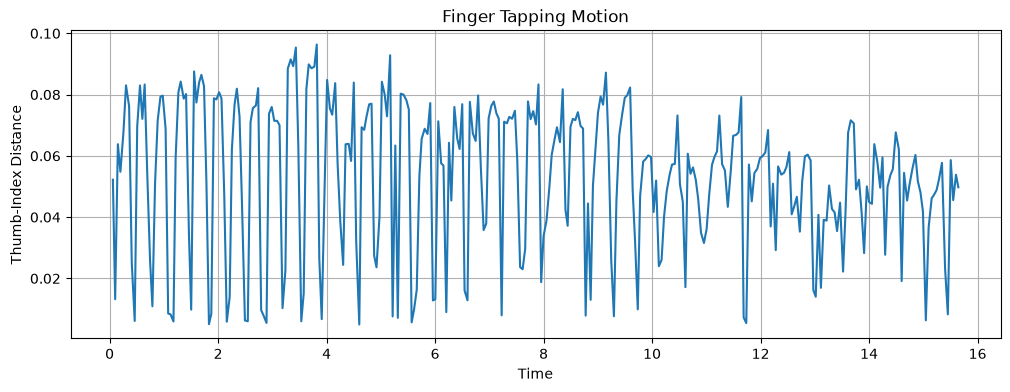

Duration: 15.584608600000138 seconds
Mean dt: 0.04870190187500043
Sampling Rate: 20.53307902772721


In [4]:
#Thumb to index finger distance calculation and plotting
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(r"C:\Users\aashi\Desktop\FYP\EDA\finger tapping individual csv\raw_data_0a713713-db3a-11ec-9567-e82aea2c97f4.csv")

df["distance"] = np.sqrt(
    (df["THUMB_TIP.x"] - df["INDEX_FINGER_TIP.x"])**2 +
    (df["THUMB_TIP.y"] - df["INDEX_FINGER_TIP.y"])**2 +
    (df["THUMB_TIP.z"] - df["INDEX_FINGER_TIP.z"])**2
)

plt.figure(figsize=(12,4))

plt.plot(df["TIME"], df["distance"])

plt.xlabel("Time")

plt.ylabel("Thumb-Index Distance")

plt.title("Finger Tapping Motion")

plt.grid(True)

plt.show()

#Motion duration
print(
    "Duration:",
    df["TIME"].max() - df["TIME"].min(),
    "seconds"
)

#Sampling rate calculation
dt = df["TIME"].diff().dropna()

print("Mean dt:", dt.mean())

print("Sampling Rate:", 1/dt.mean())

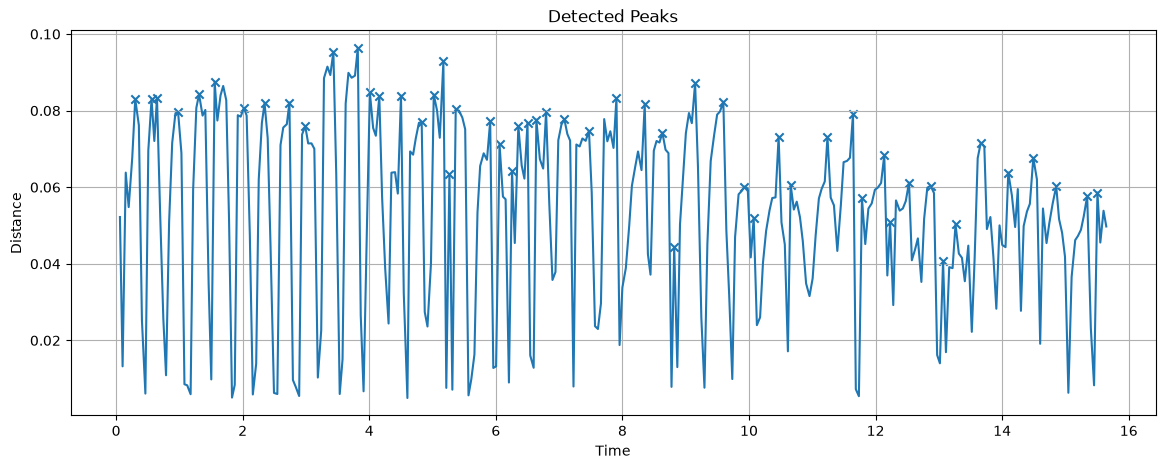

In [ ]:
#Dtect Peaks in the distance data
from scipy.signal import find_peaks

peaks, properties = find_peaks(
    df["distance"],
    prominence=0.01
)

plt.figure(figsize=(14,5))

plt.plot(df["TIME"], df["distance"])

plt.scatter(
    df["TIME"].iloc[peaks],
    df["distance"].iloc[peaks],
    marker="x"
)

plt.xlabel("Time")
plt.ylabel("Distance")
plt.title("Detected Peaks")
plt.grid(True)

plt.show()

In [ ]:
#Speed calculation
duration = (
    df["TIME"].max()
    - df["TIME"].min()
)

tap_count = len(peaks)

speed = tap_count / duration

print("Speed (taps/sec):", speed)

Speed (taps/sec): 3.464957085928967


In [15]:
#Amplitude calculation
peak_amplitudes = df["distance"].iloc[peaks]

mean_amplitude = peak_amplitudes.mean()

print("Mean Amplitude:", mean_amplitude)

Mean Amplitude: 0.07332400726222345


In [16]:
#Hesitation calculation
tap_times = df["TIME"].iloc[peaks]

intervals = tap_times.diff().dropna()

hesitation_variability = intervals.std()

print(
    "Rhythm Variability:",
    hesitation_variability
)

Rhythm Variability: 0.12984395835007295


In [17]:
#Halts calculation
largest_pause = intervals.max()

print(
    "Largest Pause:",
    largest_pause
)

Largest Pause: 0.5817342000000281


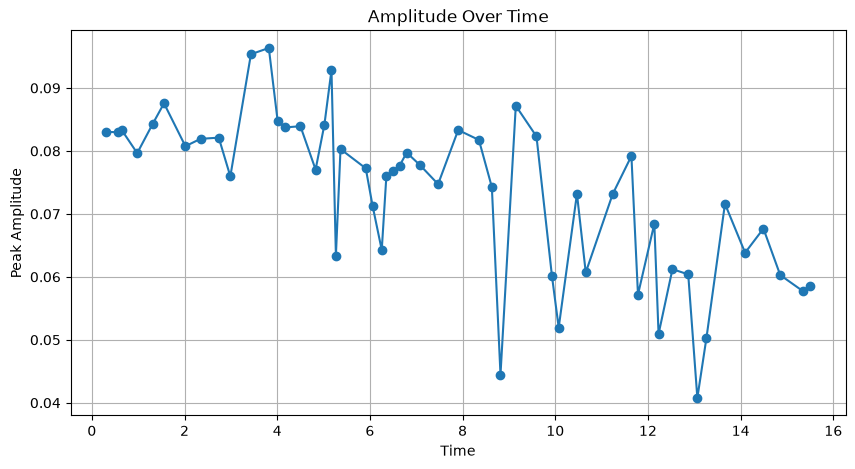

In [18]:
#Decrementing Amplitude
peak_times = df["TIME"].iloc[peaks]

peak_amplitudes = df["distance"].iloc[peaks]

plt.figure(figsize=(10,5))

plt.plot(
    peak_times,
    peak_amplitudes,
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("Peak Amplitude")

plt.title("Amplitude Over Time")

plt.grid(True)

plt.show()